# IRRM-CODEC inverse: run and analyze

This notebook mirrors the forward example, but trains and evaluates the inverse model that reconstructs a CDR3 sequence from a TCRemP embedding.

## 1. Define inputs

The AIRR file must contain `clone_id`, `junction_aa`, `v_call`, `j_call`, `locus`.
The embeddings parquet must contain `clone_id` plus either `tcremp_emb` or numeric embedding columns.

In the model pipeline, CDR3 sequences are gap-padded to a fixed length of 40 amino acids before tokenization.

In [2]:
from pathlib import Path

root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
airr_path = '/projects/immunestatus/vdjdb_olga/airr_format/trb_background_100k.tsv'  # root / 'data' / 'sample_airr.tsv'
embeddings_path = '/projects/immunestatus/vdjdb_olga/tcremp/trb_background_100k_embeddings.parquet'
output_dir = root / 'artifacts' / 'inverse_demo_trb'

airr_path, embeddings_path, output_dir

('/projects/immunestatus/vdjdb_olga/airr_format/trb_background_100k.tsv',
 '/projects/immunestatus/vdjdb_olga/tcremp/trb_background_100k_embeddings.parquet',
 PosixPath('/home/evlasova/irrm-codec/artifacts/inverse_demo_trb'))

In [3]:
import sys

sys.path.insert(0, str(root))

## 2. Preview the two files

In [4]:
import pandas as pd

airr_df = pd.read_csv(airr_path, sep='\t')
emb_df = pd.read_parquet(embeddings_path)

display(airr_df.head())
display(emb_df.head())

,junction_aa,v_call,j_call,locus
0,CATSDPGTGHQPQHF,TRBV24-1,TRBJ1-5,beta
1,CAISEGLGQGETQYF,TRBV10-3,TRBJ2-5,beta
2,CASSQVGTGVYEQYF,TRBV3-1,TRBJ2-7,beta
3,CASSLGADTQYF,TRBV13,TRBJ2-3,beta
4,CASSRTGNEQYF,TRBV27,TRBJ2-7,beta


,0_b_v,0_b_j,0_b_cdr3,1_b_v,1_b_j,1_b_cdr3,2_b_v,2_b_j,2_b_cdr3,3_b_v,...,2996_b_cdr3,2997_b_v,2997_b_j,2997_b_cdr3,2998_b_v,2998_b_j,2998_b_cdr3,2999_b_v,2999_b_j,2999_b_cdr3
0,510.0,0.0,1070.0,444.0,221.0,1200.0,776.0,0.0,890.0,776.0,...,1100.0,697.0,221.0,980.0,682.0,196.0,1320.0,488.0,196.0,890.0
1,398.0,223.0,1410.0,464.0,198.0,1120.0,782.0,223.0,1070.0,782.0,...,720.0,727.0,198.0,1040.0,686.0,197.0,1460.0,428.0,197.0,1070.0
2,775.0,221.0,1330.0,709.0,0.0,820.0,423.0,221.0,990.0,423.0,...,1160.0,670.0,0.0,680.0,615.0,107.0,1080.0,765.0,107.0,730.0
3,765.0,212.0,1460.0,761.0,213.0,730.0,709.0,212.0,1200.0,709.0,...,850.0,434.0,213.0,770.0,453.0,202.0,1090.0,763.0,202.0,580.0
4,376.0,221.0,1400.0,0.0,0.0,750.0,768.0,221.0,1120.0,768.0,...,1170.0,689.0,0.0,730.0,712.0,107.0,1210.0,492.0,107.0,500.0


## 3. Launch training

In [4]:
import subprocess

cmd = [
    sys.executable, '-m', 'irrm_codec.train_inverse',
    '--airr-path', str(airr_path),
    '--embeddings-path', str(embeddings_path),
    '--output-dir', str(output_dir),
    '--locus', 'beta',
    '--epochs', '25',
    '--max-len', '40',
    '--weight-decay', '0.00001',
    '--lr', '0.001'
]
subprocess.run(cmd, cwd=root, check=True)
cmd

2026-04-02 15:32:42,435 | INFO | starting inverse training
2026-04-02 15:32:42,456 | INFO | output_dir=/home/evlasova/irrm-codec/artifacts/inverse_demo_trb
2026-04-02 15:32:42,456 | INFO | device=cuda seed=42
2026-04-02 15:32:42,457 | INFO | hyperparameters batch_size=128 epochs=25 lr=0.001000 weight_decay=0.000010 max_len=40 num_workers=0 log_interval=10
/home/evlasova/.conda/envs/irrm-codec/lib/python3.11/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
2026-04-02 15:33:17,111 | INFO | loaded data total=100000 train=80000 val=10000 test=10000 embedding_dim=9000
2026-04-02 15:33:17,111 | INFO | dataloader batches train=625 val=79 test=79
2026-04-02 15:33:17,112 | INFO | model parameters total=51074585 trainable=51074585
2026-04-02 15:33:17,121

['/home/evlasova/.conda/envs/irrm-codec/bin/python',
 '-m',
 'irrm_codec.train_inverse',
 '--airr-path',
 '/projects/immunestatus/vdjdb_olga/airr_format/trb_background_100k.tsv',
 '--embeddings-path',
 '/projects/immunestatus/vdjdb_olga/tcremp/trb_background_100k_embeddings.parquet',
 '--output-dir',
 '/home/evlasova/irrm-codec/artifacts/inverse_demo_trb',
 '--locus',
 'beta',
 '--epochs',
 '25',
 '--max-len',
 '40',
 '--weight-decay',
 '0.00001',
 '--lr',
 '0.001']

## 4. Inspect saved metrics and merge stats

In [5]:
import json
import pandas as pd

history = json.loads((output_dir / 'history.json').read_text())
test_metrics = json.loads((output_dir / 'test_metrics.json').read_text())
data_stats = json.loads((output_dir / 'data_stats.json').read_text())
history_df = pd.json_normalize(history)

display(history_df)
display(test_metrics)
display(data_stats)

,epoch,train.loss,train.token_accuracy,train.length_accuracy,train.exact_match,train.unk_fraction,val.loss,val.token_accuracy,val.length_accuracy,val.exact_match,val.unk_fraction
0,1,0.706905,0.818634,0.649613,0.0,0.0,0.294170,0.908881,0.957971,0.040150,0.0
1,2,0.258669,0.919491,0.943287,0.0,0.0,0.179339,0.942774,0.979529,0.240407,0.0
2,3,0.181892,0.942705,0.962250,0.0,0.0,0.134237,0.957615,0.982595,0.405854,0.0
3,4,0.139640,0.955660,0.974125,0.0,0.0,0.097364,0.969096,0.991199,0.523240,0.0
4,5,0.118338,0.962378,0.978925,0.0,0.0,0.082510,0.974047,0.992682,0.586036,0.0
5,6,0.102894,0.967279,0.982300,0.0,0.0,0.070591,0.977631,0.993968,0.635384,0.0
6,7,0.089964,0.971333,0.986700,0.0,0.0,0.065844,0.979130,0.992979,0.661195,0.0
7,8,0.082558,0.973853,0.986888,0.0,0.0,0.057702,0.981547,0.995253,0.691060,0.0
8,9,0.076633,0.975652,0.987862,0.0,0.0,0.052999,0.983492,0.995550,0.710938,0.0
9,10,0.070065,0.977678,0.989287,0.0,0.0,0.046505,0.985334,0.996539,0.739221,0.0


{'loss': 0.025171056378019762,
 'token_accuracy': 0.9922962792312042,
 'length_accuracy': 0.9987143987341772,
 'exact_match': 0.8517602848101266,
 'unk_fraction': 0.0,
 'best_checkpoint_epoch': 25,
 'best_checkpoint_val_loss': 0.026674516463675833}

{'num_samples': 100000,
 'embedding_dim': 9000,
 'num_unique_clone_ids': 100000,
 'min_length': 6,
 'max_length': 25,
 'mean_length': 13.95383,
 'processed_min_length': 30,
 'processed_max_length': 30,
 'processed_mean_length': 30.0,
 'truncated_fraction': 0.0,
 'unk_sequence_fraction': 0.0,
 'max_len': 30,
 'airr_rows': 100000,
 'embeddings_rows': 100000,
 'merged_rows': 100000,
 'airr_unmatched_rows': 0,
 'embeddings_unmatched_rows': 0,
 'clone_id_column': 'clone_id',
 'embedding_column': None,
 'alignment_mode': 'row_order',
 'airr_path': '/projects/immunestatus/vdjdb_olga/airr_format/trb_background_100k.tsv',
 'embeddings_path': '/projects/immunestatus/vdjdb_olga/tcremp/trb_background_100k_embeddings.parquet',
 'train_size': 80000,
 'val_size': 10000,
 'test_size': 10000,
 'standardizer': {'mean_path': 'mean.npy', 'std_path': 'std.npy'},
 'checkpoints': {'best': 'best.pt', 'last': 'last.pt'}}

<Axes: title={'center': 'Loss by epoch'}, xlabel='epoch'>

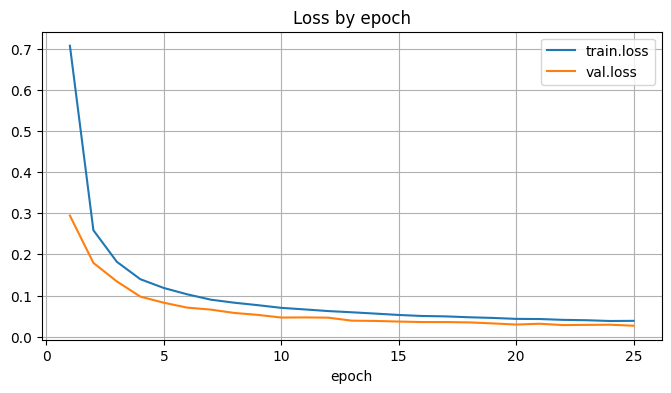

In [6]:
history_df.plot(x='epoch', y=['train.loss', 'val.loss'], figsize=(8, 4), grid=True, title='Loss by epoch')

<Axes: title={'center': 'Validation metrics by epoch'}, xlabel='epoch'>

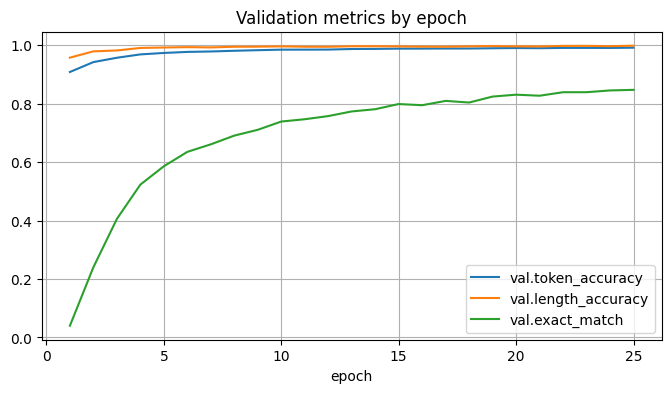

In [7]:
history_df.plot(
    x='epoch',
    y=['val.token_accuracy', 'val.length_accuracy', 'val.exact_match'],
    figsize=(8, 4),
    grid=True,
    title='Validation metrics by epoch',
)

## 5. Load a checkpoint

In [6]:
import torch
from irrm_codec.inverse_model import InverseModel

checkpoint = torch.load(output_dir / 'best.pt', map_location='cpu')
extra = checkpoint['extra']
model = InverseModel(
    embedding_dim=extra['embedding_dim'],
    max_len=extra.get('max_len', 40),
)
model.load_state_dict(checkpoint['model_state'])
model.eval()
checkpoint['metrics']

/scratch/ipykernel_2746013/2516080192.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(output_dir / 'best.pt', map_location='cpu')
/home/evlasova/

{'loss': 0.026674516463675833,
 'token_accuracy': 0.9920721287968792,
 'length_accuracy': 0.9988132911392406,
 'exact_match': 0.8477056962025317,
 'unk_fraction': 0.0}

## 6. Test the model on held-out examples

In [17]:
import numpy as np
import pandas as pd
import torch

from irrm_codec.dataio import load_airr_with_embeddings
from irrm_codec.tokenization import decode
from irrm_codec.utils import apply_standardizer, split_indices

df, emb, merge_stats = load_airr_with_embeddings(
    airr_path=airr_path,
    embeddings_path=embeddings_path,
    locus="beta",
)

train_idx, val_idx, test_idx = split_indices(
    len(df),
    train_fraction=0.8,
    val_fraction=0.1,
    seed=42,
)

test_df = df.iloc[test_idx].reset_index(drop=True)
test_emb = apply_standardizer(
    emb[test_idx],
    np.load(output_dir / "mean.npy"),
    np.load(output_dir / "std.npy"),
)

sample_size = 5000
sample_emb = torch.tensor(test_emb[:sample_size], dtype=torch.float32)

with torch.no_grad():
    pred_tokens = model.generate(sample_emb, max_len=model.max_len)

predicted_aligned = [decode(row.tolist()) for row in pred_tokens]
predicted = [decode(row.tolist(), remove_gaps=True) for row in pred_tokens]

results = pd.DataFrame({
    "target": test_df["junction_aa"].iloc[:sample_size].tolist(),
    "predicted_aligned": predicted_aligned,
    "predicted": predicted,
})

results["target_length"] = results["target"].str.len()
results["predicted_length"] = results["predicted"].str.len()
results["exact_match"] = results["target"] == results["predicted"]
results["length_match"] = results["target_length"] == results["predicted_length"]

results


,target,predicted_aligned,predicted,target_length,predicted_length,exact_match,length_match
0,CASSYRENYGYTF,CASS--------YRENYG---------YTF,CASSYRENYGYTF,13,13,True,True
1,CASSFGGTEAFF,CASS---------FGGTE---------AFF,CASSFGGTEAFF,12,12,True,True
2,CASSLAQNTEAFF,CASS--------LAQNTE---------AFF,CASSLAQNTEAFF,13,13,True,True
3,CASSQVEGETQYF,CASS--------QVEGET---------QYF,CASSQVEGETQYF,13,13,True,True
4,CSVVGGGTDTQYF,CSVV--------GGGTDT---------QYF,CSVVGGGTDTQYF,13,13,True,True
...,...,...,...,...,...,...,...
4995,CASRPRLAEGETQYF,CASR-------PRLAEGET--------QYF,CASRPRLAEGETQYF,15,15,True,True
4996,CASSQANTRAKNIQYF,CASS-------QANTRAKNI-------QYF,CASSQANTRAKNIQYF,16,16,True,True
4997,CASSLRGLGTEAFF,CASS--------LRGLGTE--------AFF,CASSLRGLGTEAFF,14,14,True,True
4998,CASRALGEQFF,CASR---------ALGE----------QFF,CASRALGEQFF,11,11,True,True


In [18]:
results.exact_match.mean()

np.float64(0.849)

In [19]:
results.length_match.mean()

np.float64(0.9984)

In [20]:
results[~results['exact_match']]

,target,predicted_aligned,predicted,target_length,predicted_length,exact_match,length_match
8,CASILTGNYNEQYF,CASL--------LTGNYNE--------QYF,CASLLTGNYNEQYF,14,14,False,True
14,CSASATGGWGREQYF,CSAS-------ATGGWGTE--------QYF,CSASATGGWGTEQYF,15,15,False,True
24,CASSHSGTSGQGAYNEQFF,CASS-----HSGTGGSGAYNE------QFF,CASSHSGTGGSGAYNEQFF,19,19,False,True
27,CSAAVTGTGEQFF,CSVA--------VTGTGE---------QFF,CSVAVTGTGEQFF,13,13,False,True
29,CASSQDYLGAWGIQYF,CASS-------QDWLGAWGI-------QYF,CASSQDWLGAWGIQYF,16,16,False,True
...,...,...,...,...,...,...,...
4961,CASKGNSYEQYF,CASR---------GNSYE---------QYF,CASRGNSYEQYF,12,12,False,True
4974,CASSQHKGLAGEKETQYF,CASS------QHKGGAGEKET------QYF,CASSQHKGGAGEKETQYF,18,18,False,True
4976,CASSQAHRQAGVSGEQFF,CASS------QAQRRQGVDGE------QFF,CASSQAQRRQGVDGEQFF,18,18,False,True
4983,CASSLDGTMTRGYTF,CASS-------LDGTLTVG--------YTF,CASSLDGTLTVGYTF,15,15,False,True


In [21]:
results[~results.length_match]

,target,predicted_aligned,predicted,target_length,predicted_length,exact_match,length_match
584,CSVDRGYTF,CSVD----------RGG----------YTF,CSVDRGGYTF,9,10,False,False
1024,CASSFICYRPLGRPNYGYTF,CASS----FFLLPLPPGRDNYG-----YTF,CASSFFLLPLPPGRDNYGYTF,20,21,False,False
1175,CASSSNPTGVIDRDRRTDTQYF,CASS----TGPRRRDRDLLTDT-----QYF,CASSTGPRRRDRDLLTDTQYF,22,21,False,False
1995,CSDGYTF,CSVG-----------G-----------YTF,CSVGGYTF,7,8,False,False
2449,CASSHTRTGGPHPVRLTDTQYF,CASS---YHGLRRRRRPRVTDTT----QYF,CASSYHGLRRRRRPRVTDTTQYF,22,23,False,False
2911,CASGLVLTALPLDSNYGYTF,CASS----LLVLLLLLPANNYG-----YTF,CASSLLVLLLLLPANNYGYTF,20,21,False,False
2942,CASSLAGHEVPAGRRYEQYF,CASS----LLAGLLLLGGRRYE-----QYF,CASSLLAGLLLLGGRRYEQYF,20,21,False,False
4767,CASSSEQYF,CASS-----------E-----------QYF,CASSEQYF,9,8,False,False


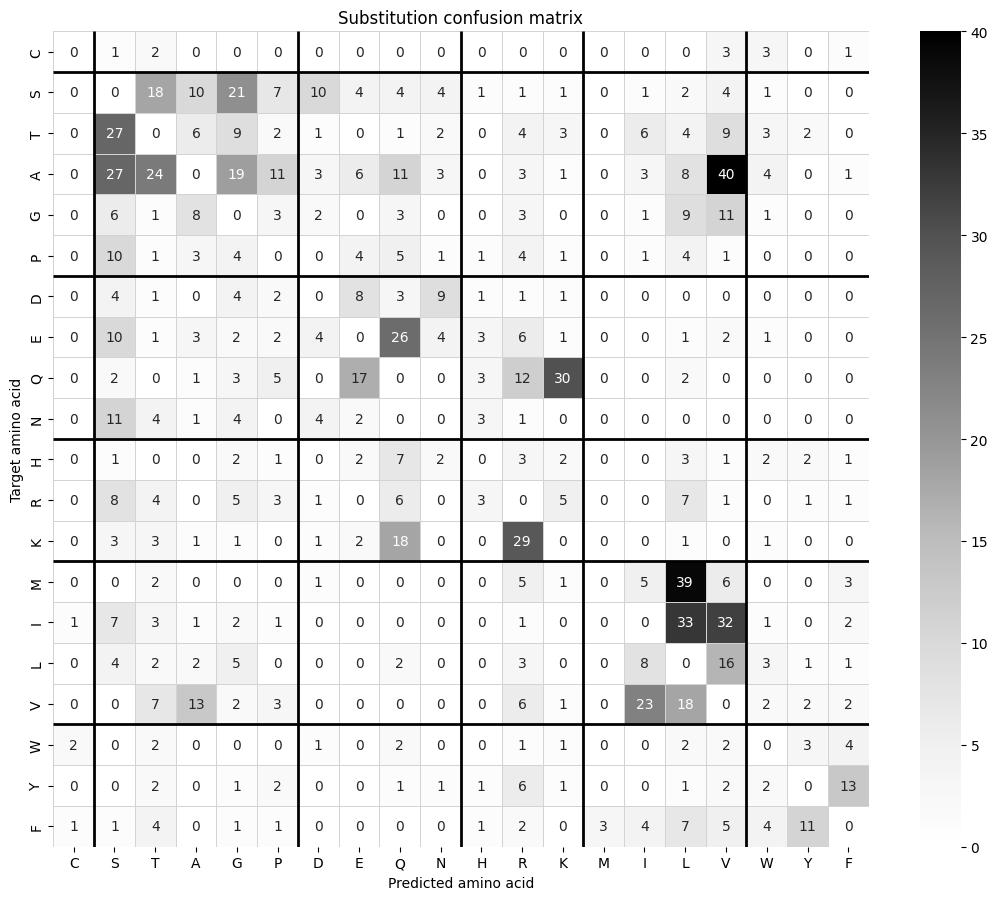

,count,fraction
within_group,553,0.485514
between_group,586,0.514486
total,1139,1.000000


In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

aa_order = list("CSTAGPDEQNHRKMILVWYF")

groups = {
    "C": set("C"),
    "STAGP": set("STAGP"),
    "DEQN": set("DEQN"),
    "HRK": set("HRK"),
    "MILV": set("MILV"),
    "WYF": set("WYF"),
}

aa_to_group = {}
for group_name, aas in groups.items():
    for aa in aas:
        aa_to_group[aa] = group_name

# берём только случаи, где длины после удаления гэпов совпадают
df_sub = results[results["length_match"]].copy()

conf_mat = pd.DataFrame(0, index=aa_order, columns=aa_order, dtype=int)

within_group_errors = 0
between_group_errors = 0
total_errors = 0

for target_seq, pred_seq in zip(df_sub["target"], df_sub["predicted"]):
    if len(target_seq) != len(pred_seq):
        continue

    for t_aa, p_aa in zip(target_seq, pred_seq):
        if t_aa not in aa_order or p_aa not in aa_order:
            continue
        if t_aa == p_aa:
            continue

        conf_mat.loc[t_aa, p_aa] += 1
        total_errors += 1

        if aa_to_group[t_aa] == aa_to_group[p_aa]:
            within_group_errors += 1
        else:
            between_group_errors += 1

plt.figure(figsize=(11, 9))
ax = sns.heatmap(
    conf_mat,
    annot=True,
    fmt="d",
    cmap="Greys",
    cbar=True,
    square=True,
    linewidths=0.5,
    linecolor="lightgray",
)

# только границы групп, без цветной заливки
boundaries = np.cumsum([1, 5, 4, 3, 4])  # C | STAGP | DEQN | HRK | MILV | WYF
for b in boundaries:
    ax.hlines(b, 0, len(aa_order), colors="black", linewidth=2)
    ax.vlines(b, 0, len(aa_order), colors="black", linewidth=2)

ax.set_xlabel("Predicted amino acid")
ax.set_ylabel("Target amino acid")
ax.set_title("Substitution confusion matrix")
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "count": [within_group_errors, between_group_errors, total_errors],
    "fraction": [
        within_group_errors / total_errors if total_errors else np.nan,
        between_group_errors / total_errors if total_errors else np.nan,
        1.0 if total_errors else np.nan,
    ],
}, index=["within_group", "between_group", "total"])

display(summary)
